# Graph Convolutional Network (late simulations)

In [107]:
batch_size = 8 
data_files = [
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc"},
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc"},
    {"label": [0], "topology_filename": "../FP11_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc"},
    {"label": [1], "topology_filename": "../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop", "coordinates_filename": "../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc"}
]
selection_string = "resid 613:754 and name CA N C" #MD2 backbone
epochs = 10
test_size = 0.20
random_state = 42
lr = 0.0001

In [108]:
data_files

[{'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc'},
 {'label': [0],
  'topology_filename': '../FP11_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc'},
 {'label': [1],
  'topology_filename': '../FP12-TLR4-MDago_monomer/SYSTEMns.prmtop',
  'coordinates_filename': '../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc'}]

In [109]:
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

from torch.nn import Embedding, CrossEntropyLoss, Linear, ReLU
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.nn import radius_graph
from torch_geometric.utils import scatter
from sklearn.model_selection import train_test_split

import MDAnalysis as mda
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import json

## Data Load

In [110]:
# u = mda.Universe("../data/md-2025-03-11/FP11ns.prmtop", "../data/md-2025-03-11/FP11-150ns.nc")
# residue_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('name CA').resnames).tolist()))
# atom_type_index = dict((key, id) for id, key in enumerate(np.unique(u.select_atoms('protein').atoms.types.tolist())))

with open('atom-list.json') as f: 
    atom_type_index = json.load(f)
with open('residue-list.json') as f: 
    residue_index = json.load(f)

In [111]:
def trajectory_to_data(u, selection_string, residue_index, atom_type_index, label):
    for fr in u.trajectory:
        x = torch.from_numpy(u.select_atoms(selection_string).positions)
        residues = list(map(lambda x: residue_index[x], u.select_atoms(selection_string).resnames))
        atom_types = list(map(lambda x: atom_type_index[x], u.select_atoms(selection_string).atoms.types.tolist()))
        d = Data(pos=x, res=torch.tensor(residues, dtype=torch.long), types=torch.tensor(atom_types, dtype=torch.long), label=torch.tensor(label, dtype=torch.long))
        yield d

In [112]:
trj = []

for file in data_files:

    u = mda.Universe(file['topology_filename'], file['coordinates_filename'])
    trj += list(trajectory_to_data(u, selection_string, residue_index, atom_type_index, file['label']))
    print(file['coordinates_filename']) # to check all files are read correctly
    print(len(u.trajectory)) # to check there are 750 frames per file
    
trj[:5]

../FP11_monomer/PRODUCTION_0/TRAJ-last75ns.nc
750
../FP11_monomer/PRODUCTION_1/TRAJ-last75ns.nc
750
../FP11_monomer/PRODUCTION_2/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_0/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_1/TRAJ-last75ns.nc
750
../FP12-TLR4-MDago_monomer/PRODUCTION_2/TRAJ-last75ns.nc
750


[Data(pos=[426, 3], res=[426], types=[426], label=[1]),
 Data(pos=[426, 3], res=[426], types=[426], label=[1]),
 Data(pos=[426, 3], res=[426], types=[426], label=[1]),
 Data(pos=[426, 3], res=[426], types=[426], label=[1]),
 Data(pos=[426, 3], res=[426], types=[426], label=[1])]

## Model

In [113]:
class GCN(torch.nn.Module):
    def __init__(self, radius):
        super().__init__()
        self.radius = radius
        self.embed_res = Embedding(num_embeddings=23, embedding_dim=128)
        self.embed_type = Embedding(num_embeddings=33, embedding_dim=128)
        #
        self.conv1_res = GCNConv(128, 64)
        self.relu1_res = ReLU()
        self.conv2_res = GCNConv(64, 32)
        self.relu2_res = ReLU()
        self.conv3_res = GCNConv(32, 16)
        # 
        self.conv1_type = GCNConv(128, 64)
        self.relu1_type = ReLU()
        self.conv2_type = GCNConv(64, 32)
        self.relu2_type = ReLU()
        self.conv3_type = GCNConv(32, 16)
        # 
        self.linear1 = Linear(32, 2)

    def forward(self, data):
        pos, res, type, batch = data.pos, data.res, data.types, data.batch
        edge_index = radius_graph(pos, r=self.radius, batch=batch)
        #
        z_res = self.embed_res(res)
        z_res = self.conv1_res(z_res, edge_index)
        z_res = self.relu1_res(z_res)
        z_res = self.conv2_res(z_res, edge_index)
        z_res = self.relu2_res(z_res)
        z_res = self.conv3_res(z_res, edge_index)
        #
        z_type = self.embed_type(type)
        z_type = self.conv1_type(z_type, edge_index)
        z_type = self.relu1_type(z_type)
        z_type = self.conv2_type(z_type, edge_index)
        z_type = self.relu2_type(z_type)
        z_type = self.conv3_type(z_type, edge_index)
        #
        z_res = scatter(z_res, data.batch, dim=0, reduce='mean')
        z_type = scatter(z_type, data.batch, dim=0, reduce='mean')
        z = torch.cat([z_res, z_type], dim=1)
        z = self.linear1(z)
        #z = F.softmax(z, dim=1) CrossEntropyLoss already does softmax at the end
        return z

In [114]:
train_trj, test_trj = train_test_split(trj, test_size=test_size, random_state=random_state)

In [115]:
print(len(train_trj))

3600


In [116]:
print(len(test_trj))

900


In [117]:
rad = [3.0, 5.0, 7.0, 10.0]
results = {}
for r in rad:
    gcn = GCN(radius=r)
    loss = CrossEntropyLoss()
    optimizer = torch.optim.Adam(gcn.parameters(), lr=lr, weight_decay=5e-4)
    train_loader = DataLoader(train_trj, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_trj, batch_size=batch_size, shuffle=True)
    history = []
    print(f"Training for radius {r}:")

    for i in tqdm.tqdm(range(epochs)):
        statistics = dict()
        statistics['training_loss'] = 0.0
        gcn.train()
        for d in train_loader:
            optimizer.zero_grad()
            z = gcn(d)
            l = loss(z, d.label)
            l.backward()
            optimizer.step()
            statistics['training_loss'] += l.item()

        gcn.eval()
        with torch.no_grad():
            statistics['test_accuracy'] = 0.0
            statistics['test_loss'] = 0.0
            for d in test_loader:
                z = gcn(d)
                l = loss(z, d.label)
                a = ((z.argmax(1) == d.label).sum())
                statistics['test_accuracy'] += a.item()
                statistics['test_loss'] += l.item()
                
        statistics['test_accuracy'] /= len(test_trj)
        statistics['test_loss'] /= ((len(test_trj) // batch_size) + 1)

        print(f"Epoch {i+1:2d} | Accuracy {statistics['test_accuracy']:.4f}")
        history.append(statistics)
        
    print(f"================================")
    results[r] = history

Training for radius 3.0:


 10%|███████████▌                                                                                                       | 1/10 [00:22<03:20, 22.32s/it]

Epoch  1 | Accuracy 0.5044


 20%|███████████████████████                                                                                            | 2/10 [00:44<02:56, 22.02s/it]

Epoch  2 | Accuracy 0.5044


...

Epoch  8 | Accuracy 0.9022


 90%|███████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [11:09<01:18, 78.46s/it]

Epoch  9 | Accuracy 0.9300


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [12:33<00:00, 75.35s/it]

Epoch 10 | Accuracy 0.9422


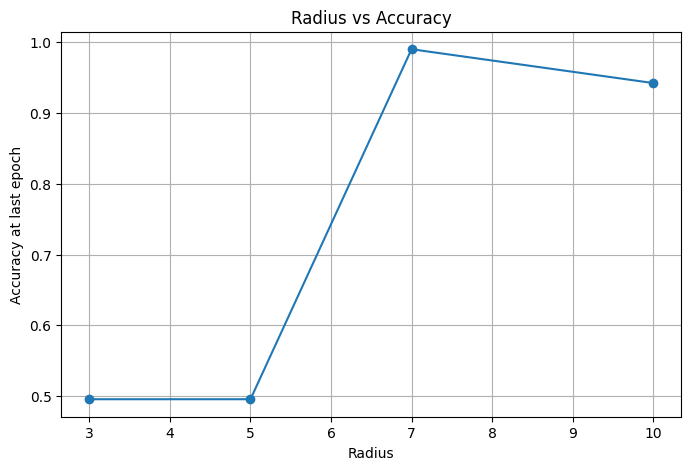

In [118]:
accuracies = [results[r][-1]['test_accuracy'] for r in rad]

plt.figure(figsize=(8,5))
plt.plot(rad, accuracies, marker='o', linestyle='-')
plt.title("Radius vs Accuracy")
plt.xlabel("Radius")
plt.ylabel("Accuracy at last epoch")
plt.grid(True)
plt.show()

In [119]:
pd.DataFrame.from_records(history)

,training_loss,test_accuracy,test_loss
0,310.650920,0.496667,0.685641
1,305.445932,0.873333,0.666742
2,291.809423,0.605556,0.628564
3,260.253903,0.884444,0.516656
4,213.144540,0.858889,0.416292
5,169.464739,0.885556,0.330077
6,139.398143,0.915556,0.268407
7,119.795566,0.902222,0.245184
8,105.330615,0.930000,0.214525
9,95.065509,0.942222,0.190929


In [ ]:
CHANGE: name="resid 613:754 and name CA N C", using only late simulations, seems to be overfitting due to less frame
    training_loss	test_accuracy	test_loss
0	0.562374	0.513333	0.701102
1	0.773349	0.486667	0.697791
2	0.666513	0.513333	0.679378
3	0.647404	1.000000	0.628916
4	0.648872	0.880000	0.547223
5	0.952839	0.486667	0.697130
6	0.435232	0.513333	0.619875
7	0.790622	0.520000	0.593141
8	0.418558	0.960000	0.462943
9	0.398797	0.973333	0.369488
10	0.340233	0.996667	0.332881
11	0.358396	0.956667	0.360120
12	0.435258	0.933333	0.424054
13	0.348645	0.940000	0.369302
14	0.332083	0.953333	0.356997

CHANGE: full simulations, good results
	training_loss	test_accuracy	test_loss
0	0.687883	0.504444	0.692985
1	0.692517	0.775556	0.691353
2	0.623324	0.640000	0.645995
3	0.506090	0.715556	0.582715
4	0.450717	0.816667	0.498017
5	0.439360	0.824444	0.476845
6	0.345354	0.784444	0.513226
7	0.418391	0.868889	0.436025
8	0.495380	0.842222	0.459707
9	0.314470	0.851111	0.461644
10	0.332093	0.878889	0.427020
11	0.313264	0.864444	0.444329
12	0.425179	0.868889	0.439064
13	0.313262	0.871111	0.438460
14	0.313262	0.913333	0.400578

CHANGE: selection_string="name CA N C", overfitting again
    training_loss	test_accuracy	test_loss
0	0.735092	0.486667	0.696513
1	0.708488	0.486667	0.693901
2	0.706887	0.486667	0.693386
3	0.692634	0.816667	0.690270
4	0.714058	0.486667	0.685859
5	0.655526	1.000000	0.654628
6	0.459406	0.513333	0.678026
7	0.898791	0.486667	0.685773
8	0.539527	0.516667	0.616767
9	0.522720	1.000000	0.520270
10	0.448007	1.000000	0.422417
11	0.491533	0.956667	0.414164
12	0.380476	0.933333	0.413461
13	0.475997	0.923333	0.400632
14	0.339070	0.980000	0.331706

CHANGE: full simulations, again good results overall
	training_loss	test_accuracy	test_loss
0	0.668922	0.504444	0.693878
1	0.677463	0.504444	0.693290
2	0.686212	0.504444	0.692931
3	0.691666	0.883333	0.690652
4	0.710071	0.495556	0.677894
5	0.681075	0.676667	0.627501
6	0.480222	0.577778	0.646426
7	0.638620	0.811111	0.512025
8	0.389760	0.802222	0.502694
9	0.331251	0.844444	0.446716
10	0.361563	0.780000	0.526556
11	0.509104	0.950000	0.364194
12	0.725616	0.856667	0.457344
13	0.359480	0.953333	0.356307
14	0.313727	0.883333	0.424348


In [ ]:
BEST PARAMETERS WITH BACKBONE ONLY AND ALL SIMULATIONS

	training_loss	test_accuracy	test_loss
0	0.668922	0.504444	0.693878
1	0.677463	0.504444	0.693290
2	0.686212	0.504444	0.692931
3	0.691666	0.883333	0.690652
4	0.710071	0.495556	0.677894
5	0.681075	0.676667	0.627501
6	0.480222	0.577778	0.646426
7	0.638620	0.811111	0.512025
8	0.389760	0.802222	0.502694
9	0.331251	0.844444	0.446716
10	0.361563	0.780000	0.526556
11	0.509104	0.950000	0.364194
12	0.725616	0.856667	0.457344
13	0.359480	0.953333	0.356307
14	0.313727	0.883333	0.424348

    training_loss	test_accuracy	test_loss
0	0.680344	0.504444	0.693183
1	0.699835	0.495556	0.693355
2	0.686886	0.504444	0.692958
3	0.695822	0.495556	0.692385
4	0.699984	0.612222	0.682742
5	0.809623	0.554444	0.677191
6	0.575478	0.603333	0.637775
7	0.535820	0.597778	0.633922
8	0.519799	0.642222	0.605968
9	0.671909	0.740000	0.546297
10	0.537757	0.807778	0.482531
11	0.618879	0.802222	0.485920
12	0.522704	0.901111	0.426193
13	0.349585	0.918889	0.406327
14	0.452205	0.890000	0.420723


In [ ]:
Training for radius 3.0:
 10%|███████████▌                                                                                                       | 1/10 [01:36<14:25, 96.19s/it]
Epoch  1 | Accuracy 0.5044
 20%|███████████████████████                                                                                            | 2/10 [03:12<12:47, 95.97s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▌                                                                                | 3/10 [04:49<11:16, 96.68s/it]
Epoch  3 | Accuracy 0.5044
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [06:34<10:00, 100.02s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [08:32<08:52, 106.57s/it]
Epoch  5 | Accuracy 0.5044
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [10:38<07:32, 113.02s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [12:50<05:57, 119.11s/it]
Epoch  7 | Accuracy 0.5044
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [15:08<04:10, 125.19s/it]
Epoch  8 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [17:27<02:09, 129.62s/it]
Epoch  9 | Accuracy 0.4956
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [19:52<00:00, 119.29s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 5.0:
 10%|███████████▍                                                                                                      | 1/10 [03:01<27:17, 181.95s/it]
Epoch  1 | Accuracy 0.4956
 20%|██████████████████████▊                                                                                           | 2/10 [06:04<24:16, 182.06s/it]
Epoch  2 | Accuracy 0.4956
 30%|██████████████████████████████████▏                                                                               | 3/10 [08:55<20:41, 177.40s/it]
Epoch  3 | Accuracy 0.5044
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [11:50<17:36, 176.12s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [14:52<14:51, 178.26s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [17:56<12:01, 180.26s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [21:04<09:08, 182.71s/it]
Epoch  7 | Accuracy 0.4956
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [24:14<06:10, 185.33s/it]
Epoch  8 | Accuracy 0.4956
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [27:30<03:08, 188.45s/it]
Epoch  9 | Accuracy 0.4956
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [30:53<00:00, 185.36s/it]
Epoch 10 | Accuracy 0.4956
================================
Training for radius 7.0:
 10%|███████████▍                                                                                                      | 1/10 [05:54<53:12, 354.75s/it]
Epoch  1 | Accuracy 0.5044
 20%|██████████████████████▊                                                                                           | 2/10 [11:52<47:32, 356.50s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▏                                                                               | 3/10 [17:50<41:41, 357.34s/it]
Epoch  3 | Accuracy 0.4956
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [23:59<36:10, 361.73s/it]
Epoch  4 | Accuracy 0.4956
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [30:19<30:42, 368.54s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [36:36<24:45, 371.37s/it]
Epoch  6 | Accuracy 0.5044
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [43:01<18:47, 375.86s/it]
Epoch  7 | Accuracy 0.4956
 80%|███████████████████████████████████████████████████████████████████████████████████████████▏                      | 8/10 [49:32<12:41, 380.72s/it]
Epoch  8 | Accuracy 0.5044
 90%|██████████████████████████████████████████████████████████████████████████████████████████████████████▌           | 9/10 [56:05<06:24, 384.36s/it]
Epoch  9 | Accuracy 0.4956
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:02:47<00:00, 376.70s/it]
Epoch 10 | Accuracy 0.5044
================================
Training for radius 10.0:
 10%|███████████▏                                                                                                    | 1/10 [07:49<1:10:23, 469.26s/it]
Epoch  1 | Accuracy 0.4956
 20%|██████████████████████▍                                                                                         | 2/10 [15:36<1:02:25, 468.25s/it]
Epoch  2 | Accuracy 0.5044
 30%|██████████████████████████████████▏                                                                               | 3/10 [23:27<54:44, 469.22s/it]
Epoch  3 | Accuracy 0.8022
 40%|█████████████████████████████████████████████▌                                                                    | 4/10 [31:27<47:22, 473.78s/it]
Epoch  4 | Accuracy 0.5044
 50%|█████████████████████████████████████████████████████████                                                         | 5/10 [39:38<39:58, 479.77s/it]
Epoch  5 | Accuracy 0.4956
 60%|████████████████████████████████████████████████████████████████████▍                                             | 6/10 [47:55<32:23, 485.84s/it]
Epoch  6 | Accuracy 0.4978
 70%|███████████████████████████████████████████████████████████████████████████████▊                                  | 7/10 [56:21<24:36, 492.27s/it]
Epoch  7 | Accuracy 0.5467
 80%|█████████████████████████████████████████████████████████████████████████████████████████▌                      | 8/10 [1:04:55<16:38, 499.33s/it]
Epoch  8 | Accuracy 0.5144
 90%|████████████████████████████████████████████████████████████████████████████████████████████████████▊           | 9/10 [1:13:35<08:25, 505.72s/it]
Epoch  9 | Accuracy 0.7911
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10 [1:22:16<00:00, 493.61s/it]
Epoch 10 | Accuracy 0.7789
================================